# 📊 Notebook 03 — Análise Visual

---

## Sobre este notebook

Chegamos à etapa final do pipeline. Aqui vamos transformar os dados tratados em visualizações que ajudam a entender o comportamento das ações ao longo do período.

Vamos criar **três gráficos**:

1. **Evolução do preço de fechamento** — para ver a tendência temporal de cada ativo
2. **Volume negociado ao longo do tempo** — para identificar períodos de maior movimentação
3. **Distribuição da variação percentual diária** — para entender a volatilidade de cada papel

O foco é clareza. Gráficos bem feitos e bem interpretados comunicam muito mais do que visualizações carregadas de informação.

---

## 1. Importação das bibliotecas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os

# Estilo global para todos os gráficos
# O seaborn_v0_8 é mais limpo e moderno do que o seaborn padrão
plt.style.use("seaborn-v0_8-whitegrid")

# Garantindo que os gráficos apareçam no notebook
%matplotlib inline

---

## 2. Leitura dos dados tratados

In [3]:
# Lendo os arquivos processados gerados no notebook anterior
dados_petr4_tratado = pd.read_csv(
    "../data/processed/petr4_dados_tratados.csv",
    index_col=0,
    parse_dates=True
)

dados_vale3_tratado = pd.read_csv(
    "../data/processed/vale3_dados_tratados.csv",
    index_col=0,
    parse_dates=True
)

dados_itub4_tratado = pd.read_csv(
    "../data/processed/itub4_dados_tratados.csv",
    index_col=0,
    parse_dates=True
)

print("✅ Dados carregados!")
print(f"PETR4: {len(dados_petr4_tratado)} registros")
print(f"VALE3: {len(dados_vale3_tratado)} registros")
print(f"ITUB4: {len(dados_itub4_tratado)} registros")

✅ Dados carregados!
PETR4: 251 registros
VALE3: 251 registros
ITUB4: 251 registros


---

## 3. Configurações gerais

Antes de plotar, vamos definir as cores e o diretório para salvar os gráficos. Centralizar isso aqui evita repetição e facilita mudanças futuras.

In [4]:
# Cores para cada ativo — escolhidas para serem visualmente distintas entre si
cor_petr4 = "#1f77b4"   # azul
cor_vale3 = "#2ca02c"   # verde
cor_itub4 = "#d62728"   # vermelho

# Diretório onde os gráficos serão salvos
caminho_pasta_imagens = "../images"
os.makedirs(caminho_pasta_imagens, exist_ok=True)

print(f"Gráficos serão salvos em: {caminho_pasta_imagens}")

Gráficos serão salvos em: ../images


---

## 📈 Gráfico 1 — Evolução do Preço de Fechamento

O preço de fechamento é uma das métricas mais acompanhadas no mercado financeiro. Ele representa o último valor negociado em cada dia e é amplamente usado para avaliar tendências.

Nesse gráfico, vamos plotar as três ações juntas para facilitar a comparação visual entre elas ao longo do período.

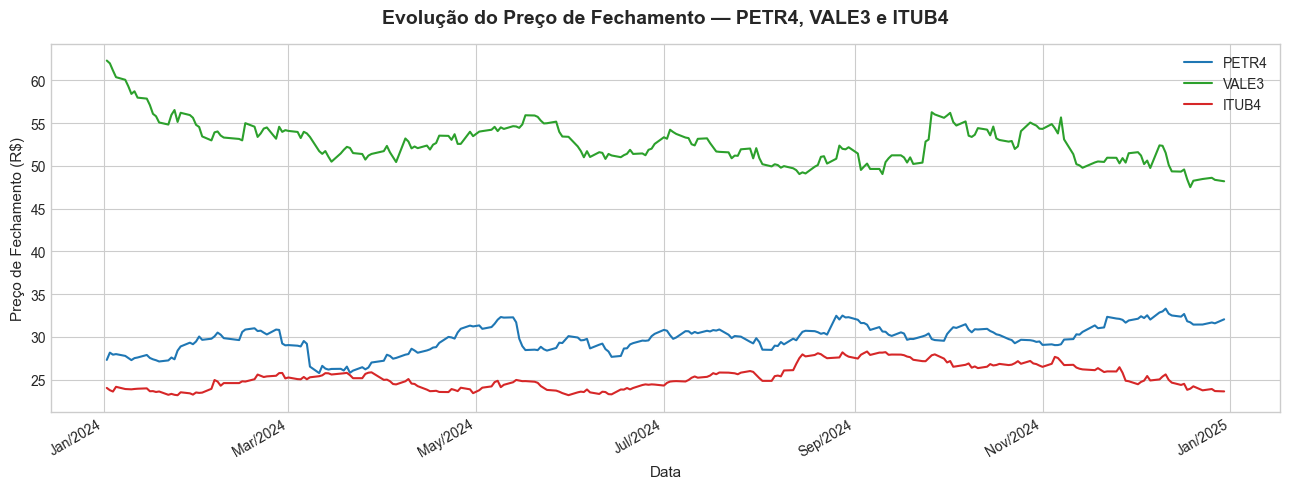

✅ Gráfico 1 salvo!


In [5]:
figura_preco_fechamento, eixo_preco = plt.subplots(figsize=(13, 5))

# Plotando cada ativo com sua cor e rótulo
eixo_preco.plot(
    dados_petr4_tratado.index,
    dados_petr4_tratado["Close"],
    color=cor_petr4,
    label="PETR4",
    linewidth=1.5
)

eixo_preco.plot(
    dados_vale3_tratado.index,
    dados_vale3_tratado["Close"],
    color=cor_vale3,
    label="VALE3",
    linewidth=1.5
)

eixo_preco.plot(
    dados_itub4_tratado.index,
    dados_itub4_tratado["Close"],
    color=cor_itub4,
    label="ITUB4",
    linewidth=1.5
)

# Formatando os eixos e adicionando rótulos
eixo_preco.set_title(
    "Evolução do Preço de Fechamento — PETR4, VALE3 e ITUB4",
    fontsize=14,
    fontweight="bold",
    pad=15
)
eixo_preco.set_xlabel("Data", fontsize=11)
eixo_preco.set_ylabel("Preço de Fechamento (R$)", fontsize=11)
eixo_preco.legend(fontsize=10)

# Formatando o eixo de datas para ficar mais legível
eixo_preco.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
eixo_preco.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
figura_preco_fechamento.autofmt_xdate()

plt.tight_layout()
plt.savefig(f"{caminho_pasta_imagens}/grafico_01_preco_fechamento.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Gráfico 1 salvo!")

### 🔍 Interpretação

O gráfico mostra as trajetórias de preço de fechamento dos três ativos ao longo do período analisado. Alguns pontos interessantes para observar:

- **Escalas diferentes**: os três ativos operam em faixas de preço bastante distintas. ITUB4 e VALE3 costumam ter valores mais próximos entre si, enquanto PETR4 pode variar bastante dependendo do cenário macroeconômico.
- **Tendências**: ao acompanhar as linhas, é possível identificar períodos de alta sustentada, correções e movimentos de lateral. Esses padrões geralmente refletem eventos econômicos ou setoriais específicos.
- **Correlação visual**: em alguns períodos, os três ativos tendem a se mover na mesma direção (reflexo de movimentos do Ibovespa como um todo). Em outros, se descolam, evidenciando fatores idiossincráticos de cada setor.

---

## 📦 Gráfico 2 — Volume Negociado ao Longo do Tempo

O volume negociado representa a quantidade de ações que trocaram de mão em cada dia. Picos de volume geralmente coincidem com eventos relevantes — divulgação de resultados, notícias do setor, movimentos macroeconômicos — e são um sinal de interesse do mercado naquele ativo.

Vamos plotar os três ativos em subgráficos separados para facilitar a leitura, já que os volumes são de magnitudes bem diferentes.

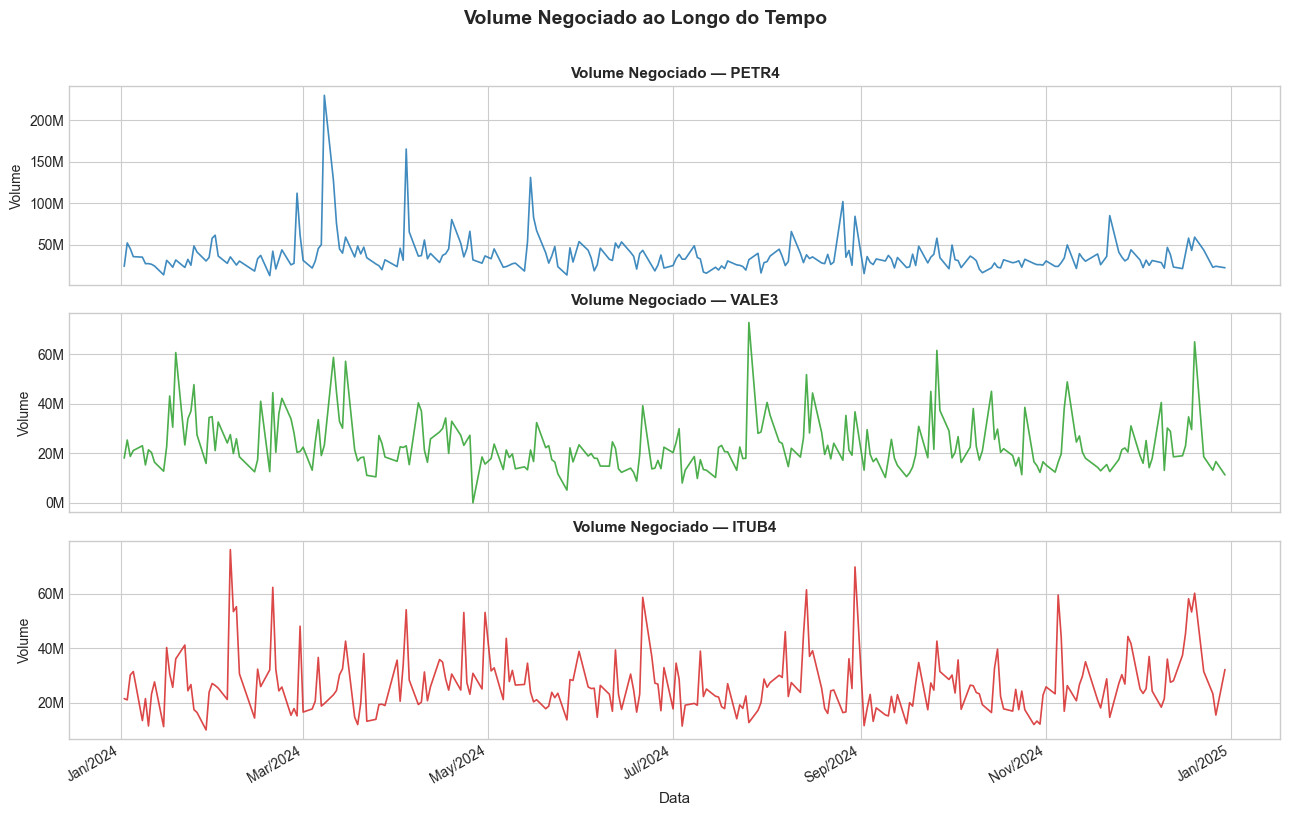

✅ Gráfico 2 salvo!


In [6]:
figura_volume, eixos_volume = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Dicionário para iterar de forma organizada
ativos_para_plotar = [
    (dados_petr4_tratado, "PETR4", cor_petr4),
    (dados_vale3_tratado, "VALE3", cor_vale3),
    (dados_itub4_tratado, "ITUB4", cor_itub4),
]

for eixo, (dados_ativo, nome_ativo, cor_ativo) in zip(eixos_volume, ativos_para_plotar):
    sns.lineplot(
        data=dados_ativo,
        x=dados_ativo.index,
        y="Volume",
        ax=eixo,
        color=cor_ativo,
        linewidth=1.2,
        alpha=0.85
    )
    eixo.set_ylabel("Volume", fontsize=10)
    eixo.set_title(f"Volume Negociado — {nome_ativo}", fontsize=11, fontweight="bold")

    # Formatando o eixo Y para mostrar valores em milhões
    eixo.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda valor, _: f"{valor/1_000_000:.0f}M")
    )

# Configurando o eixo X só no último subgráfico (eles compartilham o eixo)
eixos_volume[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
eixos_volume[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
eixos_volume[-1].set_xlabel("Data", fontsize=11)

figura_volume.suptitle(
    "Volume Negociado ao Longo do Tempo",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
figura_volume.autofmt_xdate()
plt.savefig(f"{caminho_pasta_imagens}/grafico_02_volume_negociado.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Gráfico 2 salvo!")

### 🔍 Interpretação

O volume negociado é um indicador complementar ao preço e ajuda a contextualizar os movimentos de mercado:

- **Picos isolados** costumam indicar reações do mercado a notícias específicas — resultados trimestrais, fatos relevantes, mudanças de política de dividendos ou eventos macroeconômicos.
- **PETR4** tende a apresentar os maiores volumes absolutos por ser uma das ações mais negociadas do Ibovespa, com grande participação de investidores institucionais.
- **Períodos de volume baixo** geralmente ocorrem em feriados ou em semanas com poucas notícias relevantes para o setor.
- A comparação entre os três painéis mostra que os picos de volume nem sempre são simultâneos — o que reforça que cada ativo reage a seus próprios catalisadores setoriais.

---

## 🔔 Gráfico 3 — Distribuição da Variação Percentual Diária

A variação percentual diária mede o quanto o preço de cada ação oscilou entre abertura e fechamento em cada dia. Analisar a distribuição dessas variações ajuda a entender a **volatilidade** de cada ativo.

Ativos mais voláteis têm uma distribuição mais larga — ou seja, grandes variações tanto positivas quanto negativas são mais frequentes. Ativos mais estáveis concentram a maior parte das variações próximas a zero.

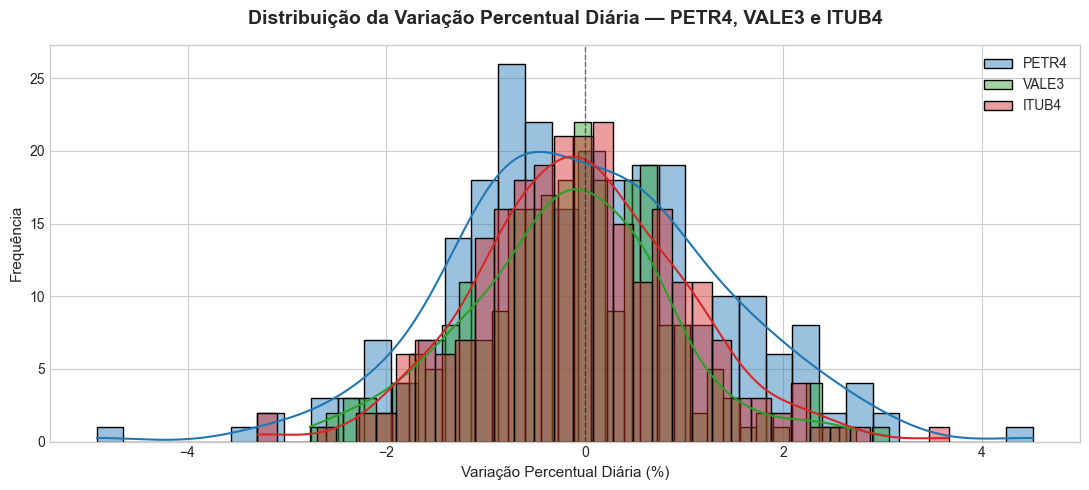

✅ Gráfico 3 salvo!


In [7]:
figura_distribuicao, eixo_distribuicao = plt.subplots(figsize=(11, 5))

# Plotando a distribuição de cada ativo com histograma e KDE sobreposta
sns.histplot(
    data=dados_petr4_tratado["variacao_percentual_diaria"],
    ax=eixo_distribuicao,
    color=cor_petr4,
    label="PETR4",
    kde=True,
    alpha=0.45,
    bins=35
)

sns.histplot(
    data=dados_vale3_tratado["variacao_percentual_diaria"],
    ax=eixo_distribuicao,
    color=cor_vale3,
    label="VALE3",
    kde=True,
    alpha=0.45,
    bins=35
)

sns.histplot(
    data=dados_itub4_tratado["variacao_percentual_diaria"],
    ax=eixo_distribuicao,
    color=cor_itub4,
    label="ITUB4",
    kde=True,
    alpha=0.45,
    bins=35
)

# Linha de referência no zero para facilitar a leitura
eixo_distribuicao.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

eixo_distribuicao.set_title(
    "Distribuição da Variação Percentual Diária — PETR4, VALE3 e ITUB4",
    fontsize=14,
    fontweight="bold",
    pad=15
)
eixo_distribuicao.set_xlabel("Variação Percentual Diária (%)", fontsize=11)
eixo_distribuicao.set_ylabel("Frequência", fontsize=11)
eixo_distribuicao.legend(fontsize=10)

plt.tight_layout()
plt.savefig(
    f"{caminho_pasta_imagens}/grafico_03_distribuicao_variacao.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print("✅ Gráfico 3 salvo!")

### 🔍 Interpretação

O histograma mostra como se distribuem as oscilações diárias de cada ativo. Algumas observações importantes:

- **Formato em sino**: a maioria das ações tende a apresentar uma distribuição aproximadamente normal (em sino) centrada próxima ao zero, o que indica que na maior parte dos dias as variações são pequenas.
- **Largura da distribuição = volatilidade**: quanto mais larga a distribuição, mais volátil é o ativo. Ações como PETR4, que dependem do preço do petróleo e da política de dividendos, tendem a ter distribuições mais espalhadas.
- **Caudas longas**: valores extremos (positivos ou negativos) nas bordas do histograma indicam dias de forte oscilação — geralmente associados a eventos específicos como crises, resultados ou decisões do governo.
- **Comparação entre ativos**: observando as três distribuições sobrepostas, conseguimos ter uma noção visual de qual ativo foi mais volátil no período, sem precisar calcular métricas formais como desvio padrão.

---

## ✅ Conclusão do Projeto

Chegamos ao final do pipeline. Ao longo dos três notebooks, percorremos todas as etapas básicas de um projeto de dados financeiros:

| Etapa | O que foi feito |
|---|---|
| **Coleta** | Dados históricos dos últimos 12 meses coletados via yfinance |
| **Tratamento** | Remoção de nulos, conversão de datas, seleção de colunas e criação de nova métrica |
| **Análise** | Três visualizações cobrindo preço, volume e distribuição de variações |

### Possíveis próximos passos

Esse projeto foi propositalmente simples, mas serve como base para evoluções futuras:

- Adicionar mais ativos ou ampliar o período de análise
- Calcular métricas de risco como desvio padrão e beta
- Construir uma análise de correlação entre os ativos
- Criar visualizações interativas com `plotly`
- Automatizar a atualização dos dados com agendamento

> 💡 O mais importante desse projeto não foi o resultado final, mas o processo: pensar em como organizar as etapas, documentar as decisões e manter o código legível para quem vier depois — incluindo eu mesmo daqui a algumas semanas.